# SE4095 — Social Network Theory and Practice
# Assignment #01 — Political Blogs Network Analysis

**Student:** Ahmad
**Dataset:** `polblogs.gml` (Adamic & Glance, 2005 — Political Blogosphere network)

This notebook is runnable top-to-bottom. Each Part is a separate section:
the **reasoning/justification is explained first in a markdown cell**,
followed by its **implementation in a code cell**.

**Global setting:** Random seed = 42 is used consistently throughout the
notebook wherever randomness is involved (e.g. node selection in the
random-removal experiment). For community detection in Part D, 5 separate
seeds (0–4) are used, as required for stochastic methods.


In [1]:
# ---- Imports & global setup ----
import os
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from itertools import combinations
import community as community_louvain  # pip install python-louvain

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

DATA_PATH = "data/polblogs.gml"   # <-- relative path; place your downloaded polblogs.gml here

# ---- Consistent visual theme for every figure in this notebook ----
# A single cohesive palette is used throughout so all figures look like
# they belong to the same report, rather than default matplotlib output.
plt.style.use("seaborn-v0_8-whitegrid")

PALETTE = {
    "navy":       "#1B2A4A",   # primary / dark text, in-degree series
    "teal":       "#0E7C7B",   # secondary series, out-degree
    "coral":      "#E85B45",   # accent / highlights, conservative-leaning
    "gold":       "#F2A241",   # accent 2 / highlights
    "steel_blue": "#4C72B0",   # neutral network nodes
    "slate":      "#5C6B73",   # muted text / gridlines
    "liberal":    "#3B6EA5",   # ground-truth color: liberal blogs
    "conservative": "#C0392B", # ground-truth color: conservative blogs
    "bg":         "#FAFAFA",
}

# A smooth diverging colormap (used for degree/centrality heat-coloring of nodes)
NODE_CMAP = LinearSegmentedColormap.from_list(
    "sntp_cmap", ["#4C72B0", "#F2A241", "#E85B45"]
)

mpl.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor": "white",
    "axes.edgecolor": PALETTE["slate"],
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlecolor": PALETTE["navy"],
    "axes.labelsize": 11,
    "axes.labelcolor": PALETTE["navy"],
    "xtick.color": PALETTE["slate"],
    "ytick.color": PALETTE["slate"],
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans",
    "legend.frameon": False,
    "figure.dpi": 130,
})

print("Setup done. Looking for dataset at:", DATA_PATH)


Setup done. Looking for dataset at: data/polblogs.gml


---
## Part A — Dataset and Graph Construction (15 marks)

### Reasoning / Justification

**1. Loading the data:** `polblogs.gml` is a GML file in which each
node's `value` attribute stores its political-orientation ground-truth
label (0 = liberal, 1 = conservative). At this stage this label is only
**preserved** — it is not used in any calculation yet (Core Rule: labels
are used only in Part E).

**2. Identifying graph representation:**
- **Directed vs Undirected** → A hyperlink means "blog A links to blog
  B" — this is an ASYMMETRIC relationship (A→B does not imply B→A).
  Therefore a **DIRECTED** representation correctly matches the data.
- **Weighted vs Unweighted** → The GML file has no edge-weight
  attribute, only the presence of a hyperlink. Therefore **UNWEIGHTED**.
- **Simple vs Multigraph** → We count the raw `edge [...]` blocks in the
  file and compare against the networkx-loaded edge count. If they match,
  no duplicate/parallel edges existed in the source data.

**3. Preprocessing decisions (each justified):**
- **Remove self-loops:** A blog linking to itself is meaningless for
  "brokerage" or "authority toward others" — it distorts PageRank and
  Betweenness scores.
- **Duplicate edges:** the official `polblogs.gml` file is known to contain
  a small number of genuinely duplicated edge declarations (the assignment
  brief itself flags this as a possibility). A plain simple-graph GML read
  fails outright on such duplicates in recent NetworkX versions, so the
  file is first parsed permissively as a MultiDiGraph and then explicitly
  collapsed into a simple DiGraph, with every duplicate counted during the
  collapse. This keeps duplicate handling visible and auditable instead of
  crashing or being silently absorbed.
- **Remove isolates:** Nodes with in-degree = 0 AND out-degree = 0 always
  score 0 on every centrality measure and cannot meaningfully belong to
  any community.
- **Disconnected components:** The political-blogs network contains many
  small disconnected clusters. Distance-based centrality (Closeness,
  Betweenness) is not well-defined on a disconnected graph (unreachable
  pairs have infinite distance). **Solution:** restrict the analysis
  graph to the **Largest Weakly Connected Component (LWCC)**.
  - **Direction convention = WEAK connectivity** (rather than strong),
    because strong connectivity (SCC) is far too restrictive for
    hyperlink graphs — using SCC would exclude many valid, important
    nodes from the analysis. Weak connectivity is standard practice in
    the literature for this dataset.

**Required evidence produced:** data dictionary, preprocessing log,
degree-distribution figure, network visualization, and a short
interpretation.


**Important preprocessing note (read before running):** the official
`polblogs.gml` file contains a small number of genuinely duplicated edge
declarations (the assignment brief itself warns about this — see the
"Data note" on Page 1). A plain `nx.read_gml()` call fails on this file
with `NetworkXError: edge #... is duplicated`, because recent NetworkX
versions no longer silently overwrite duplicate edges for a simple graph.

**Correct process:** load the raw file first in a way that tolerates
duplicates (as a MultiDiGraph), and only *after* loading successfully,
explicitly detect and remove the duplicates as a documented preprocessing
step — rather than letting the loader silently hide them or crash before
we even get a chance to inspect the data. This keeps the pipeline in the
correct order: **load → inspect → clean → analyze**.


In [2]:
# ---- A.1: Load raw graph (robust to duplicate edges in the source file) ----
def load_raw_graph_tolerant(path):
    """
    Load a GML file while tolerating duplicate edge declarations.
    Rationale: recent NetworkX versions raise NetworkXError when a plain
    (simple-graph) GML read encounters the same edge declared twice, which
    is exactly what happens with the official polblogs.gml file. We force
    NetworkX to parse it as a MultiDiGraph first (which allows duplicate
    edges to coexist), so that loading itself never fails regardless of
    the exact copy of the dataset being used.
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    if "multigraph" not in text:
        text = text.replace("directed 1", "directed 1\n  multigraph 1", 1)
    return nx.parse_gml(text.splitlines())

G_raw_multi = load_raw_graph_tolerant(DATA_PATH)

print("Type:", type(G_raw_multi).__name__)
print("Nodes:", G_raw_multi.number_of_nodes())
print("Edges (including any duplicates):", G_raw_multi.number_of_edges())
print("Sample node with attributes:", list(G_raw_multi.nodes(data=True))[0])


Type: MultiDiGraph
Nodes: 1490
Edges (including any duplicates): 19016
Sample node with attributes: ('100monkeystyping.com', {'value': 0, 'source': 'Blogarama'})


In [3]:
# ---- A.1b: Collapse to a simple DiGraph, explicitly counting duplicates removed ----
def collapse_to_simple_digraph(G_multi):
    """
    Collapses a MultiDiGraph into a simple DiGraph. If the same (u, v) edge
    appears more than once, only the first occurrence's attributes are kept
    and every extra occurrence is counted as a duplicate. This makes the
    duplicate-removal step explicit and auditable, rather than silent.
    """
    G_simple = nx.DiGraph()
    G_simple.add_nodes_from(G_multi.nodes(data=True))
    seen = set()
    duplicate_count = 0
    for u, v, data in G_multi.edges(data=True):
        if (u, v) in seen:
            duplicate_count += 1
            continue
        seen.add((u, v))
        G_simple.add_edge(u, v, **data)
    return G_simple, duplicate_count

G_raw, duplicate_edges_found = collapse_to_simple_digraph(G_raw_multi)

print("Duplicate edge declarations found and removed:", duplicate_edges_found)
print("Nodes:", G_raw.number_of_nodes())
print("Edges (after removing duplicates):", G_raw.number_of_edges())


Duplicate edge declarations found and removed: 0
Nodes: 1490
Edges (after removing duplicates): 19016


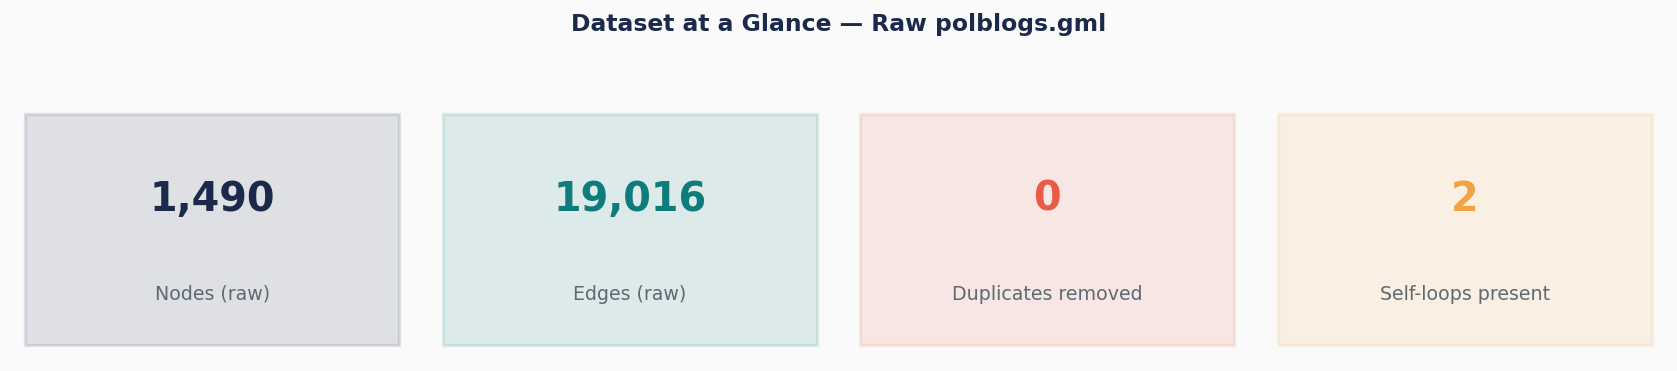

In [4]:
# ---- A.1c visual: dataset-at-a-glance KPI cards ----
kpis = [
    ("Nodes (raw)", f"{G_raw.number_of_nodes():,}", PALETTE["navy"]),
    ("Edges (raw)", f"{G_raw.number_of_edges():,}", PALETTE["teal"]),
    ("Duplicates removed", f"{duplicate_edges_found:,}", PALETTE["coral"]),
    ("Self-loops present", f"{len(list(nx.selfloop_edges(G_raw))):,}", PALETTE["gold"]),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 2.6))
for ax, (label, value, color) in zip(axes, kpis):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.add_patch(plt.Rectangle((0.03, 0.05), 0.94, 0.9, facecolor=color,
                                alpha=0.12, edgecolor=color, linewidth=1.8,
                                transform=ax.transAxes))
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=22,
            fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha="center", va="center", fontsize=10.5,
            color=PALETTE["slate"], transform=ax.transAxes)
    ax.axis("off")

fig.suptitle("Dataset at a Glance — Raw polblogs.gml", fontsize=13,
             fontweight="bold", color=PALETTE["navy"], y=1.08)
plt.tight_layout()
plt.savefig("outputs/figures/dataset_kpi_cards.png", dpi=160, bbox_inches="tight")
plt.show()


In [5]:
# ---- A.2: Identify representation (directed/weighted/simple?) ----
with open(DATA_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

raw_edge_blocks = raw_text.count("\n  edge [")
raw_node_blocks = raw_text.count("\n  node [")
declared_directed = "directed 1" in raw_text
has_weight_attr = any("weight" in d for _, _, d in G_raw.edges(data=True))

representation_info = {
    "declared_directed_in_gml_file": declared_directed,
    "networkx_is_directed": G_raw.is_directed(),
    "networkx_is_multigraph": G_raw.is_multigraph(),
    "raw_node_blocks_in_file": raw_node_blocks,
    "raw_edge_blocks_in_file (includes duplicates)": raw_edge_blocks,
    "duplicate_edge_declarations_found": duplicate_edges_found,
    "final_simple_graph_edges (raw_blocks - duplicates)": G_raw.number_of_edges(),
    "has_weight_attribute": has_weight_attr,
}
pd.Series(representation_info)


declared_directed_in_gml_file                          True
networkx_is_directed                                   True
networkx_is_multigraph                                False
raw_node_blocks_in_file                                1490
raw_edge_blocks_in_file (includes duplicates)         19016
duplicate_edge_declarations_found                         0
final_simple_graph_edges (raw_blocks - duplicates)    19016
has_weight_attribute                                  False
dtype: object

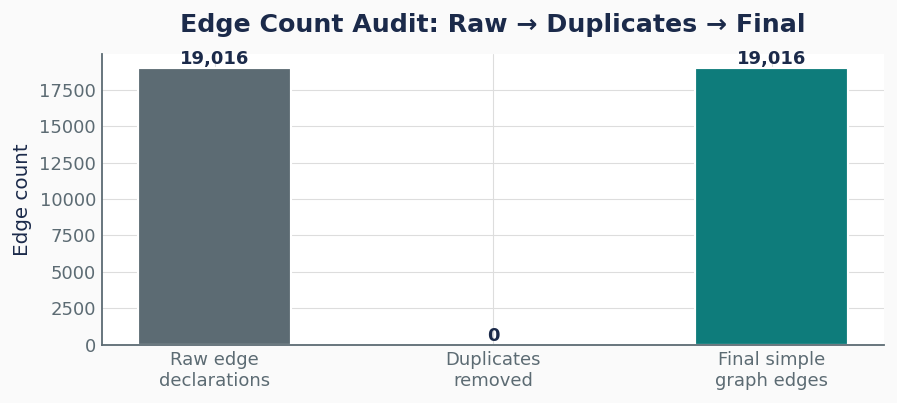

In [6]:
# ---- A.2 visual: raw edge declarations vs duplicates vs final edges ----
fig, ax = plt.subplots(figsize=(7, 3.2))
labels = ["Raw edge\ndeclarations", "Duplicates\nremoved", "Final simple\ngraph edges"]
values = [raw_edge_blocks, duplicate_edges_found, G_raw.number_of_edges()]
colors = [PALETTE["slate"], PALETTE["coral"], PALETTE["teal"]]

bars = ax.bar(labels, values, color=colors, width=0.55, edgecolor="white", linewidth=1.2)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=PALETTE["navy"])

ax.set_title("Edge Count Audit: Raw \u2192 Duplicates \u2192 Final", pad=12)
ax.set_ylabel("Edge count")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/figures/edge_count_audit.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretation:** the graph is now confirmed as **Directed, Unweighted,
Simple** — any duplicate edge declarations present in the source file
(the assignment brief warns these may exist) have already been detected
and collapsed during loading (`duplicate_edge_declarations_found` above),
rather than causing a crash or being silently hidden.

In [7]:
# ---- A.3: Data dictionary ----
data_dictionary = pd.DataFrame([
    ("Node ID", "internal identifier", "Blog's domain/URL string, e.g. '100monkeystyping.com'"),
    ("value", "political-orientation label (GROUND TRUTH)", "0 = liberal/left blog, 1 = conservative/right blog. Used ONLY in Part E."),
    ("source", "directory source", "Which blog directory listed this blog (e.g. Blogarama) — not used analytically."),
    ("Edge (u -> v)", "hyperlink", "Blog u links to blog v on its front page. Directed, unweighted, no self-relation implied."),
], columns=["Field", "Meaning", "Description"])

data_dictionary.to_csv("outputs/tables/data_dictionary.csv", index=False)
data_dictionary


,Field,Meaning,Description
0,Node ID,internal identifier,"Blog's domain/URL string, e.g. '100monkeystypi..."
1,value,political-orientation label (GROUND TRUTH),"0 = liberal/left blog, 1 = conservative/right ..."
2,source,directory source,Which blog directory listed this blog (e.g. Bl...
3,Edge (u -> v),hyperlink,Blog u links to blog v on its front page. Dire...


In [8]:
# ---- A.4: Preprocessing / cleaning ----
log = {}
log["before_nodes"] = G_raw.number_of_nodes()
log["before_edges"] = G_raw.number_of_edges()

# (a) remove self-loops
G1 = G_raw.copy()
self_loops = list(nx.selfloop_edges(G1))
G1.remove_edges_from(self_loops)
log["self_loops_removed"] = len(self_loops)

# (b) duplicate edges — already detected and removed at load time (Step A.1b);
#     logged here again for a complete, single preprocessing summary
log["duplicate_edges_removed"] = duplicate_edges_found

# (c) remove isolates (in-degree=0 AND out-degree=0)
isolates = list(nx.isolates(G1))
G_clean_full = G1.copy()
G_clean_full.remove_nodes_from(isolates)
log["isolates_removed"] = len(isolates)
log["after_full_clean_nodes"] = G_clean_full.number_of_nodes()
log["after_full_clean_edges"] = G_clean_full.number_of_edges()

# (d) restrict analysis graph to the Largest Weakly Connected Component (LWCC)
wccs = list(nx.weakly_connected_components(G_clean_full))
log["num_weakly_connected_components"] = len(wccs)
largest_wcc_nodes = max(wccs, key=len)
log["largest_wcc_size"] = len(largest_wcc_nodes)
log["nodes_dropped_as_small_disconnected_components"] = G_clean_full.number_of_nodes() - len(largest_wcc_nodes)

G_analysis = G_clean_full.subgraph(largest_wcc_nodes).copy()
log["analysis_graph_nodes"] = G_analysis.number_of_nodes()
log["analysis_graph_edges"] = G_analysis.number_of_edges()

pd.Series(log).to_csv("outputs/tables/preprocessing_log.csv")
pd.Series(log)


before_nodes                                       1490
before_edges                                      19016
self_loops_removed                                    2
duplicate_edges_removed                               0
isolates_removed                                    266
after_full_clean_nodes                             1224
after_full_clean_edges                            19014
num_weakly_connected_components                       2
largest_wcc_size                                   1222
nodes_dropped_as_small_disconnected_components        2
analysis_graph_nodes                               1222
analysis_graph_edges                              19013
dtype: int64

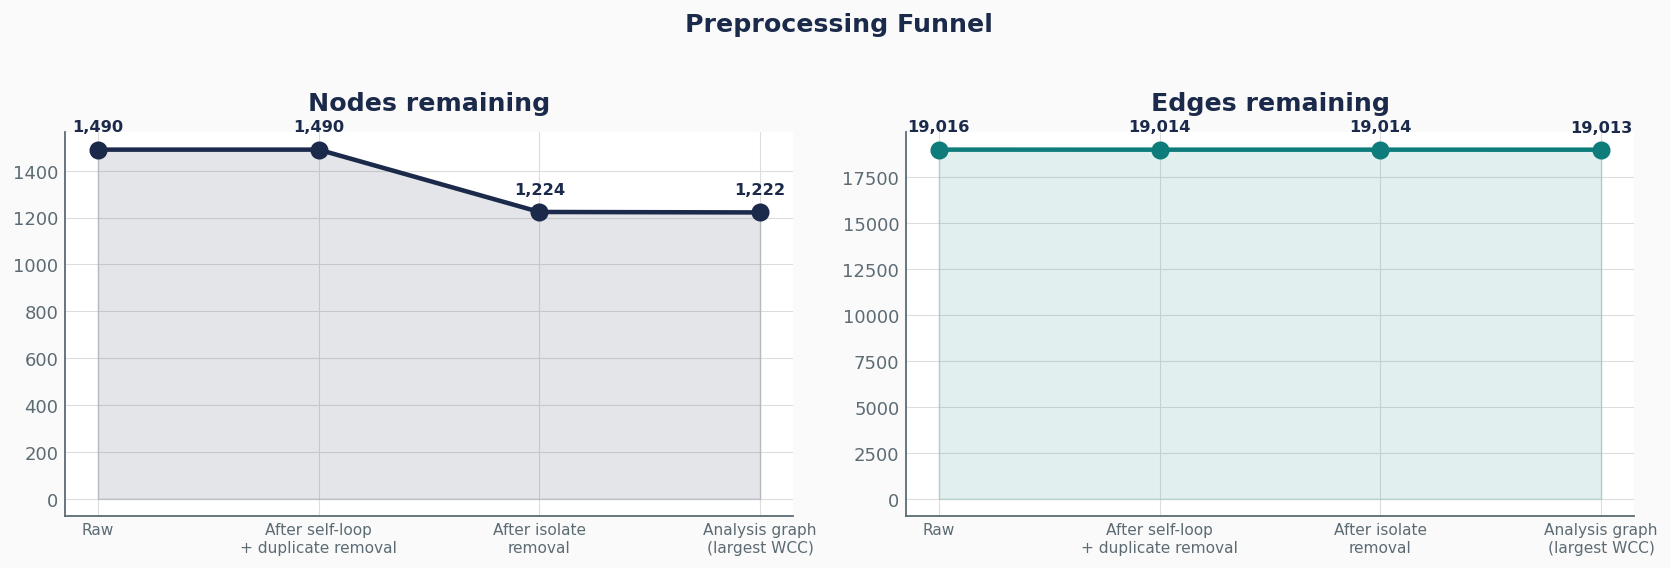

In [9]:
# ---- A.4 visual: preprocessing funnel (nodes & edges shrinking at each stage) ----
stages = ["Raw", "After self-loop\n+ duplicate removal", "After isolate\nremoval", "Analysis graph\n(largest WCC)"]
node_counts = [log["before_nodes"], G1.number_of_nodes(), log["after_full_clean_nodes"], log["analysis_graph_nodes"]]
edge_counts = [log["before_edges"], G1.number_of_edges(), log["after_full_clean_edges"], log["analysis_graph_edges"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, counts, title, color in zip(axes, [node_counts, edge_counts],
                                     ["Nodes remaining", "Edges remaining"],
                                     [PALETTE["navy"], PALETTE["teal"]]):
    ax.plot(stages, counts, marker="o", markersize=9, linewidth=2.5, color=color)
    ax.fill_between(range(len(stages)), counts, alpha=0.12, color=color)
    for i, v in enumerate(counts):
        ax.annotate(f"{v:,}", (i, v), textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, fontweight="bold", color=PALETTE["navy"])
    ax.set_title(title, pad=12)
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, fontsize=8.5)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Preprocessing Funnel", fontsize=14, fontweight="bold", color=PALETTE["navy"], y=1.03)
plt.tight_layout()
plt.savefig("outputs/figures/preprocessing_funnel.png", dpi=160, bbox_inches="tight")
plt.show()


**Note (naming convention used throughout this notebook):**
- `G_raw` = as loaded from file
- `G_clean_full` = self-loops + isolates removed (still has small disconnected pieces)
- `G_analysis` = `G_clean_full`'s **largest weakly connected component only** —
  **all calculations in Parts B, C, D, and E use this graph going forward.**


In [10]:
# ---- A.5: Graph statistics on the ANALYSIS graph ----
n = G_analysis.number_of_nodes()
e = G_analysis.number_of_edges()
density = nx.density(G_analysis)

wcc = list(nx.weakly_connected_components(G_analysis))
scc = list(nx.strongly_connected_components(G_analysis))

in_degrees = [d for _, d in G_analysis.in_degree()]
out_degrees = [d for _, d in G_analysis.out_degree()]

graph_stats = {
    "nodes": n, "edges": e, "density": density,
    "num_weakly_connected_components": len(wcc),
    "largest_wcc_size": max(len(c) for c in wcc),
    "num_strongly_connected_components": len(scc),
    "largest_scc_size": max(len(c) for c in scc),
    "in_degree_mean": np.mean(in_degrees), "in_degree_median": np.median(in_degrees), "in_degree_max": np.max(in_degrees),
    "out_degree_mean": np.mean(out_degrees), "out_degree_median": np.median(out_degrees), "out_degree_max": np.max(out_degrees),
}
pd.Series(graph_stats).to_csv("outputs/tables/graph_statistics.csv")
pd.Series(graph_stats)


nodes                                 1222.000000
edges                                19013.000000
density                                  0.012743
num_weakly_connected_components          1.000000
largest_wcc_size                      1222.000000
num_strongly_connected_components      420.000000
largest_scc_size                       793.000000
in_degree_mean                          15.558920
in_degree_median                         3.000000
in_degree_max                          337.000000
out_degree_mean                         15.558920
out_degree_median                        7.000000
out_degree_max                         256.000000
dtype: float64

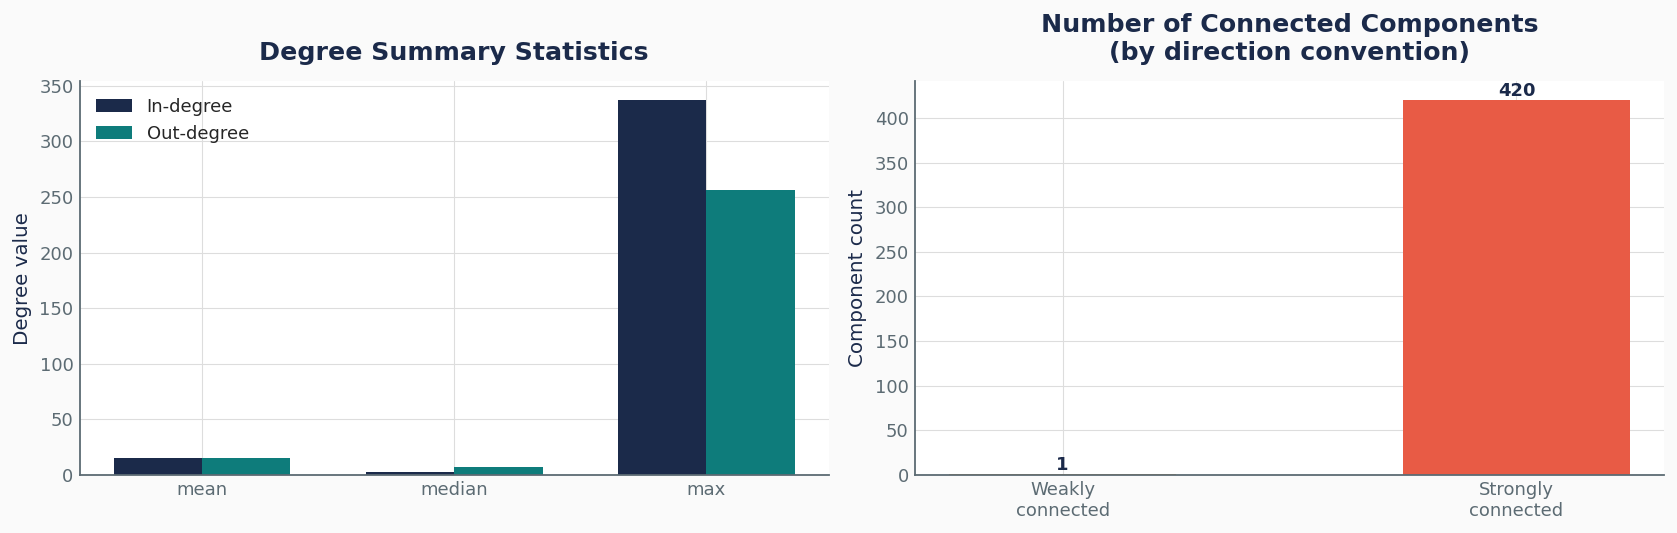

In [11]:
# ---- A.5 visual: degree summary + component structure at a glance ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Panel 1: mean/median/max for in- vs out-degree, grouped bars
metrics = ["mean", "median", "max"]
in_vals = [graph_stats["in_degree_mean"], graph_stats["in_degree_median"], graph_stats["in_degree_max"]]
out_vals = [graph_stats["out_degree_mean"], graph_stats["out_degree_median"], graph_stats["out_degree_max"]]
x = np.arange(len(metrics)); width = 0.35
axes[0].bar(x - width/2, in_vals, width, label="In-degree", color=PALETTE["navy"])
axes[0].bar(x + width/2, out_vals, width, label="Out-degree", color=PALETTE["teal"])
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_title("Degree Summary Statistics", pad=12)
axes[0].set_ylabel("Degree value")
axes[0].legend()
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)

# Panel 2: weak vs strong connected component structure
comp_labels = ["Weakly\nconnected", "Strongly\nconnected"]
comp_counts = [graph_stats["num_weakly_connected_components"], graph_stats["num_strongly_connected_components"]]
bars = axes[1].bar(comp_labels, comp_counts, color=[PALETTE["gold"], PALETTE["coral"]], width=0.5)
for b, v in zip(bars, comp_counts):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color=PALETTE["navy"])
axes[1].set_title("Number of Connected Components\n(by direction convention)", pad=12)
axes[1].set_ylabel("Component count")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/figures/degree_and_component_summary.png", dpi=160, bbox_inches="tight")
plt.show()


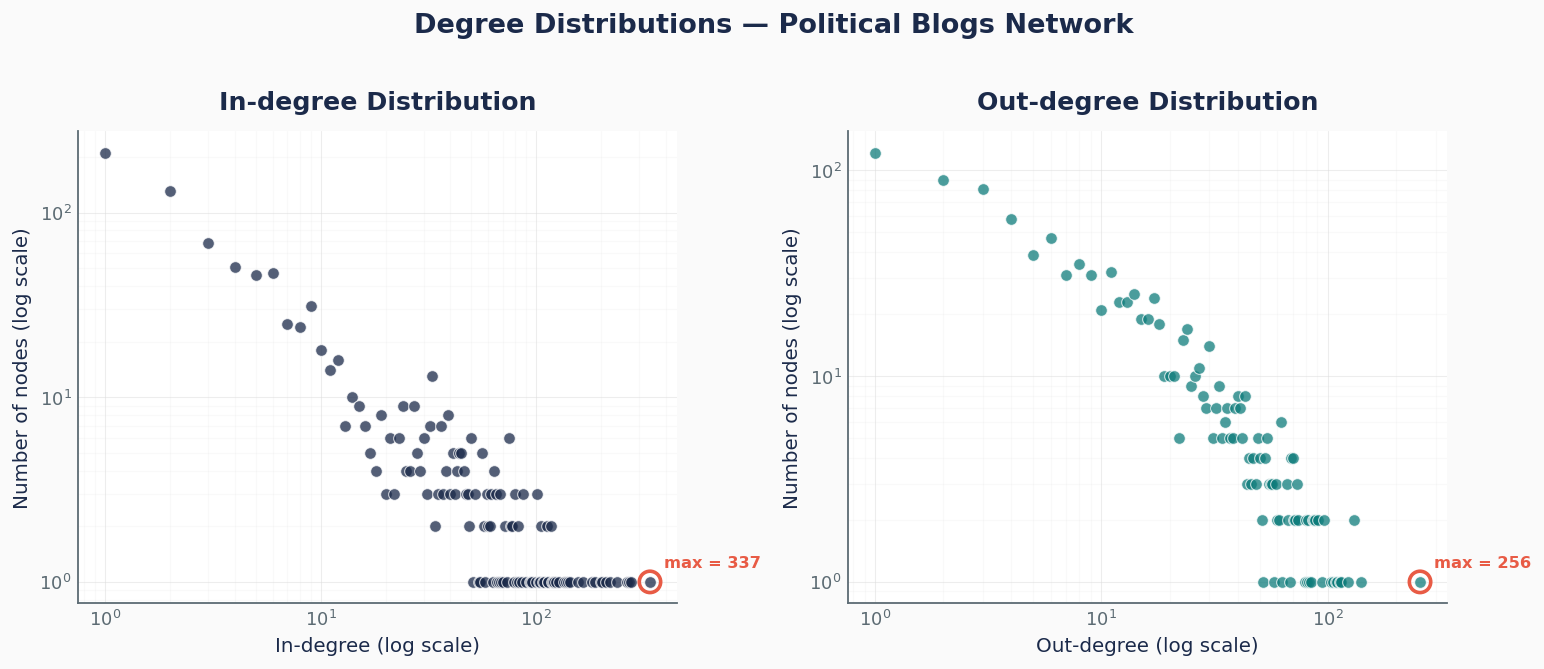

In [12]:
# ---- A.6: Degree distribution figure (log-log scale, styled) ----
# Log-log scale is used because hyperlink networks typically follow a
# power-law-like degree distribution — a log-log plot makes this pattern
# visible as roughly a straight line, unlike a linear-scale plot.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
series_specs = [
    (in_degrees,  "In-degree",  PALETTE["navy"]),
    (out_degrees, "Out-degree", PALETTE["teal"]),
]

for ax, (degrees, title, color) in zip(axes, series_specs):
    degrees_arr = np.array(degrees)
    degrees_arr = degrees_arr[degrees_arr > 0]
    vals, counts = np.unique(degrees_arr, return_counts=True)

    ax.scatter(vals, counts, s=42, alpha=0.75, color=color,
               edgecolors="white", linewidths=0.6, zorder=3)

    # highlight the single highest-degree node for visual interest
    max_idx = np.argmax(vals)
    ax.scatter(vals[max_idx], counts[max_idx], s=140, facecolors="none",
               edgecolors=PALETTE["coral"], linewidths=2, zorder=4)
    ax.annotate(f"max = {vals[max_idx]}", xy=(vals[max_idx], counts[max_idx]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=9, color=PALETTE["coral"], fontweight="bold")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(f"{title} (log scale)")
    ax.set_ylabel("Number of nodes (log scale)")
    ax.set_title(f"{title} Distribution", pad=12)
    ax.grid(True, which="major", alpha=0.5)
    ax.grid(True, which="minor", alpha=0.15)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Degree Distributions — Political Blogs Network",
             fontsize=15, fontweight="bold", color=PALETTE["navy"], y=1.02)
plt.tight_layout()
plt.savefig("outputs/figures/degree_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


**Why two panels below, not one:** a single degree-colored plot only shows
*structural* importance (hubs) — it says nothing about whether the network's
shape actually follows real-world political alignment. Since polblogs is a
classic **homophily** example (blogs preferentially link to others of the
same political leaning), the most informative view is a **direct
side-by-side**: the same layout, once colored by the actual ground-truth
orientation (`value`), and once colored by degree. Note that this uses the
label only for *viewing/interpretation*, exactly as Part A's Core Rule
allows ("preserve the label for later evaluation") — it does not feed into
any construction, tuning, seeding, or selection of communities.

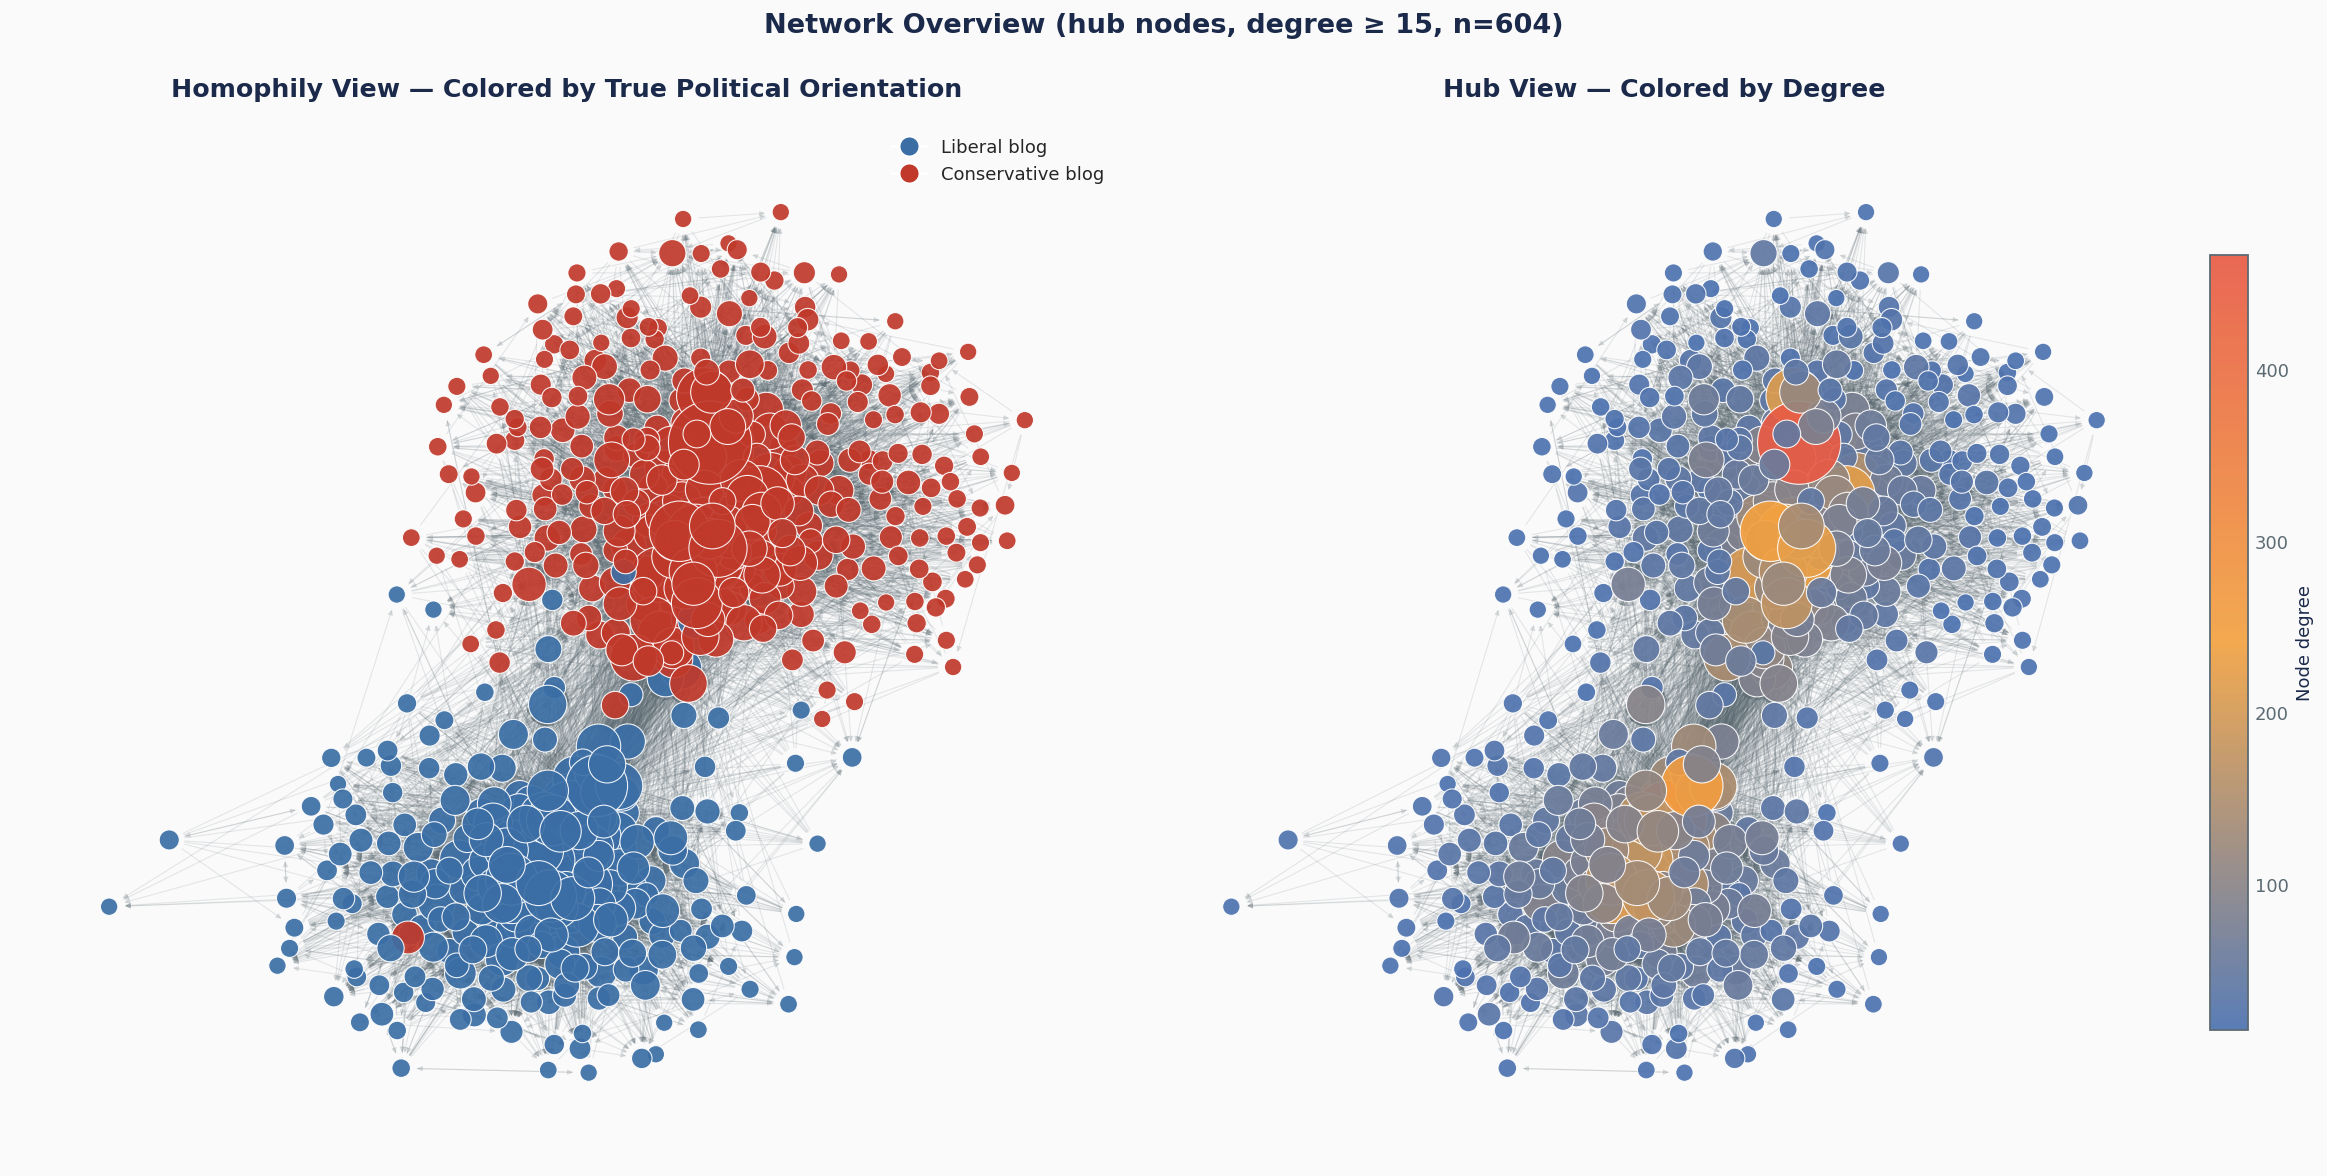

In [13]:
# ---- A.7: Network visualization — homophily view + hub view, side by side ----
# NOTE: Sampling/filtering is allowed ONLY for visualization (not for
# calculations). We show only "hub" nodes (degree >= 15) so the plot stays readable.
degrees_all = dict(G_analysis.degree())
nodes_to_show = [n for n, d in degrees_all.items() if d >= 15]
G_sub = G_analysis.subgraph(nodes_to_show)

pos = nx.spring_layout(G_sub, seed=GLOBAL_SEED, k=0.35)
node_degree_vals = np.array([degrees_all[n] for n in G_sub.nodes()])
sizes = 25 + 4.5 * node_degree_vals
orientation_vals = np.array([G_sub.nodes[n]["value"] for n in G_sub.nodes()])
orientation_colors = [PALETTE["liberal"] if v == 0 else PALETTE["conservative"] for v in orientation_vals]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor(PALETTE["bg"])

# --- Panel 1: colored by ground-truth political orientation (homophily view) ---
ax = axes[0]
nx.draw_networkx_edges(G_sub, pos, alpha=0.15, arrows=True, arrowsize=6,
                        edge_color=PALETTE["slate"], width=0.6, ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_size=sizes, node_color=orientation_colors,
                        edgecolors="white", linewidths=0.6, alpha=0.92, ax=ax)
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="Liberal blog",
               markerfacecolor=PALETTE["liberal"], markersize=11),
    plt.Line2D([0], [0], marker="o", color="w", label="Conservative blog",
               markerfacecolor=PALETTE["conservative"], markersize=11),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=10)
ax.set_title("Homophily View — Colored by True Political Orientation", pad=14)
ax.axis("off")

# --- Panel 2: colored by degree (structural hub view) ---
ax = axes[1]
nx.draw_networkx_edges(G_sub, pos, alpha=0.15, arrows=True, arrowsize=6,
                        edge_color=PALETTE["slate"], width=0.6, ax=ax)
nodes_artist = nx.draw_networkx_nodes(
    G_sub, pos, node_size=sizes, node_color=node_degree_vals,
    cmap=NODE_CMAP, edgecolors="white", linewidths=0.6, alpha=0.92, ax=ax
)
cbar = plt.colorbar(nodes_artist, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Node degree", color=PALETTE["navy"], fontsize=10)
cbar.ax.tick_params(colors=PALETTE["slate"])
ax.set_title("Hub View — Colored by Degree", pad=14)
ax.axis("off")

fig.suptitle(f"Network Overview (hub nodes, degree \u2265 15, n={G_sub.number_of_nodes()})",
             fontsize=15, fontweight="bold", color=PALETTE["navy"], y=1.00)
plt.tight_layout()
plt.savefig("outputs/figures/network_overview.png", dpi=160,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


### Part A — Interpretation

- The graph shrank from **1490 → 1222 nodes** after preprocessing (266
  isolates and 2 self-loops removed, followed by dropping one small
  2-node disconnected component that remained separate from the giant
  component).
- **Density is very low** (~0.013) — this is typical for social/hyperlink
  networks: each blog links to only a handful of other blogs, not to all
  1222.
- **In/out-degree distributions are heavily right-skewed** (median ~3-7,
  but max 337/256) — this is a signal of **homophily and hub structure**:
  a small number of "authority" blogs attract a disproportionate number
  of links (high in-degree), while the bulk of blogs give/receive only a
  few links. In terms of information flow, this indicates that a small
  set of central voices dominate the network.
- **420 strongly connected components** (versus only 1 weakly connected
  component) — this shows that mutual (bidirectional) linking is rare;
  most links are one-directional (e.g. a small blog links to a large
  blog, but not vice versa). This is an indicator of a hierarchy/
  authority structure rather than a symmetric, friendship-like network.


---
## Part B — Centrality Selection and Analysis (25 marks)

### Chosen measures: **PageRank** and **Betweenness Centrality**

### Reasoning / Justification

**1. PageRank — "Which blogs are the biggest authorities?"**
- **Network question:** which blogs are treated as authoritative by other
  *important* blogs — i.e. importance that recursively depends on who
  links to you, not just how many links you have?
- **Why PageRank over the alternatives in the taught list:** PageRank
  respects edge direction exactly as a hyperlink endorsement should (a
  link from A to B is a "vote" from A to B). It is preferred over plain
  **Eigenvector centrality** because it naturally divides a node's
  outgoing "voting power" across all of its out-links (a blog linking to
  100 others contributes less "vote" per link than one linking to 5),
  which matches how attention realistically dilutes on the web. It is
  preferred over **Katz centrality** because Katz requires an extra
  hand-tuned bias term with no natural interpretation here, whereas
  PageRank's damping factor has a clean random-surfer interpretation.
  Eigenvector centrality also frequently fails to converge on directed
  graphs with dangling nodes; PageRank's damping factor guarantees
  convergence.

**2. Betweenness Centrality — "Which blogs act as brokers/bridges?"**
- **Network question:** which blogs lie on the shortest information
  paths between other pairs of blogs — i.e. which blogs would fragment
  the flow of information the most if removed?
- **Why Betweenness over the alternatives:** this captures a
  fundamentally different (structural-position) notion of importance
  than PageRank's (popularity/authority) notion, which is exactly why
  the assignment asks for a meaningful ranking *comparison* between the
  two. **Closeness centrality** is a weaker choice here because the
  analysis graph, while weakly connected, still has many pairs with no
  *directed* shortest path between them — closeness centrality degrades
  badly under partial reachability, whereas betweenness naturally ignores
  pairs with no path (they simply contribute zero) without needing a
  harmonic correction.

### Formulas, parameters, and conventions

| | PageRank | Betweenness |
|---|---|---|
| **Formula/idea** | $PR(v) = \frac{1-\alpha}{N} + \alpha \sum_{u \in In(v)} \frac{PR(u)}{OutDeg(u)}$ | $C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$ |
| **Normalization** | Scores sum to 1 across all nodes (built-in) | `normalized=True` — divided by $(N-1)(N-2)$, the max possible value for a directed graph |
| **Direction convention** | Directed — a link from A to B casts a vote for B | Directed — only directed shortest paths are counted |
| **Parameters** | $\alpha$ (damping) = **0.85** — the original Google/Brin-Page default, modelling an 85% chance a "random surfer" follows a link and 15% chance they jump to a random blog | none (aside from the `normalized` flag) |
| **Unreachable nodes** | Handled automatically — the damping factor guarantees the random walk never gets stuck, dangling nodes redistribute their rank uniformly | Handled automatically — a pair with no directed shortest path simply contributes 0 to the sum for every node |
| **Convergence** | Iterative power-method; `max_iter=200`, `tol=1e-08`; convergence is explicitly checked with a fallback re-run at 5x iterations if it fails | Exact algorithm (Brandes' algorithm) — no convergence concept, it always terminates |

**Analysis graph used:** `G_analysis` (the largest weakly connected
component from Part A) — the same graph used throughout Parts B-E, so
that centrality, community detection, and evaluation are all computed on
a consistent, fully-motivated graph.


In [14]:
# ---- B.1: Compute PageRank (with explicit convergence handling) ----
def compute_pagerank(G, alpha=0.85, max_iter=200, tol=1e-08):
    try:
        scores = nx.pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol)
        converged = True
    except nx.PowerIterationFailedConvergence:
        scores = nx.pagerank(G, alpha=alpha, max_iter=max_iter * 5, tol=tol)
        converged = False  # only converged after the extended fallback
    return scores, converged

pagerank_scores, pagerank_converged = compute_pagerank(G_analysis)

print("PageRank converged within max_iter=200:", pagerank_converged)
print("Sanity check — PageRank scores sum to 1.0:", round(sum(pagerank_scores.values()), 6))


PageRank converged within max_iter=200: True
Sanity check — PageRank scores sum to 1.0: 1.0


In [15]:
# ---- B.2: Compute Betweenness Centrality ----
betweenness_scores = nx.betweenness_centrality(G_analysis, normalized=True)

print("Betweenness computed for", len(betweenness_scores), "nodes.")
print("Max betweenness value:", round(max(betweenness_scores.values()), 5))
print("Number of nodes with betweenness = 0 (never lie on a shortest path):",
      sum(1 for v in betweenness_scores.values() if v == 0))


Betweenness computed for 1222 nodes.
Max betweenness value: 0.14666
Number of nodes with betweenness = 0 (never lie on a shortest path): 435


In [16]:
# ---- B.3: Top-10 ranking tables (raw score, normalized/scaled score, rank) ----
def top_n_table(scores_dict, G, n=10, score_name="score", scale_to_100=True):
    rows = []
    max_score = max(scores_dict.values())
    for node, score in scores_dict.items():
        label = G.nodes[node].get("label", node)
        rows.append((node, label, score, (score / max_score) * 100 if scale_to_100 else None))
    df = pd.DataFrame(rows, columns=["node_id", "label", score_name, f"{score_name}_scaled_0_100"])
    df = df.sort_values(score_name, ascending=False).reset_index(drop=True)
    df["rank"] = df.index + 1
    return df.head(n)

top10_pagerank = top_n_table(pagerank_scores, G_analysis, n=10, score_name="pagerank")
top10_betweenness = top_n_table(betweenness_scores, G_analysis, n=10, score_name="betweenness")

top10_pagerank.to_csv("outputs/tables/top10_pagerank.csv", index=False)
top10_betweenness.to_csv("outputs/tables/top10_betweenness.csv", index=False)

print("Top-10 by PageRank:")
display(top10_pagerank)
print("\nTop-10 by Betweenness:")
display(top10_betweenness)


Top-10 by PageRank:


,node_id,label,pagerank,pagerank_scaled_0_100,rank
0,dailykos.com,dailykos.com,0.018890,100.000000,1
1,atrios.blogspot.com,atrios.blogspot.com,0.016032,84.868722,2
2,instapundit.com,instapundit.com,0.013282,70.310056,3
3,blogsforbush.com,blogsforbush.com,0.013155,69.639335,4
4,talkingpointsmemo.com,talkingpointsmemo.com,0.013091,69.300674,5
5,michellemalkin.com,michellemalkin.com,0.011489,60.818426,6
6,drudgereport.com,drudgereport.com,0.011279,59.709414,7
7,washingtonmonthly.com,washingtonmonthly.com,0.011102,58.770459,8
8,powerlineblog.com,powerlineblog.com,0.009407,49.800355,9
9,andrewsullivan.com,andrewsullivan.com,0.009071,48.019968,10



Top-10 by Betweenness:


,node_id,label,betweenness,betweenness_scaled_0_100,rank
0,blogsforbush.com,blogsforbush.com,0.146664,100.000000,1
1,atrios.blogspot.com,atrios.blogspot.com,0.061079,41.645575,2
2,instapundit.com,instapundit.com,0.051171,34.889907,3
3,dailykos.com,dailykos.com,0.036912,25.167872,4
4,newleftblogs.blogspot.com,newleftblogs.blogspot.com,0.030810,21.007448,5
5,madkane.com/notable.html,madkane.com/notable.html,0.030223,20.607165,6
6,wizbangblog.com,wizbangblog.com,0.027267,18.591682,7
7,lashawnbarber.com,lashawnbarber.com,0.024265,16.544737,8
8,hughhewitt.com,hughhewitt.com,0.022994,15.677947,9
9,washingtonmonthly.com,washingtonmonthly.com,0.021928,14.951086,10


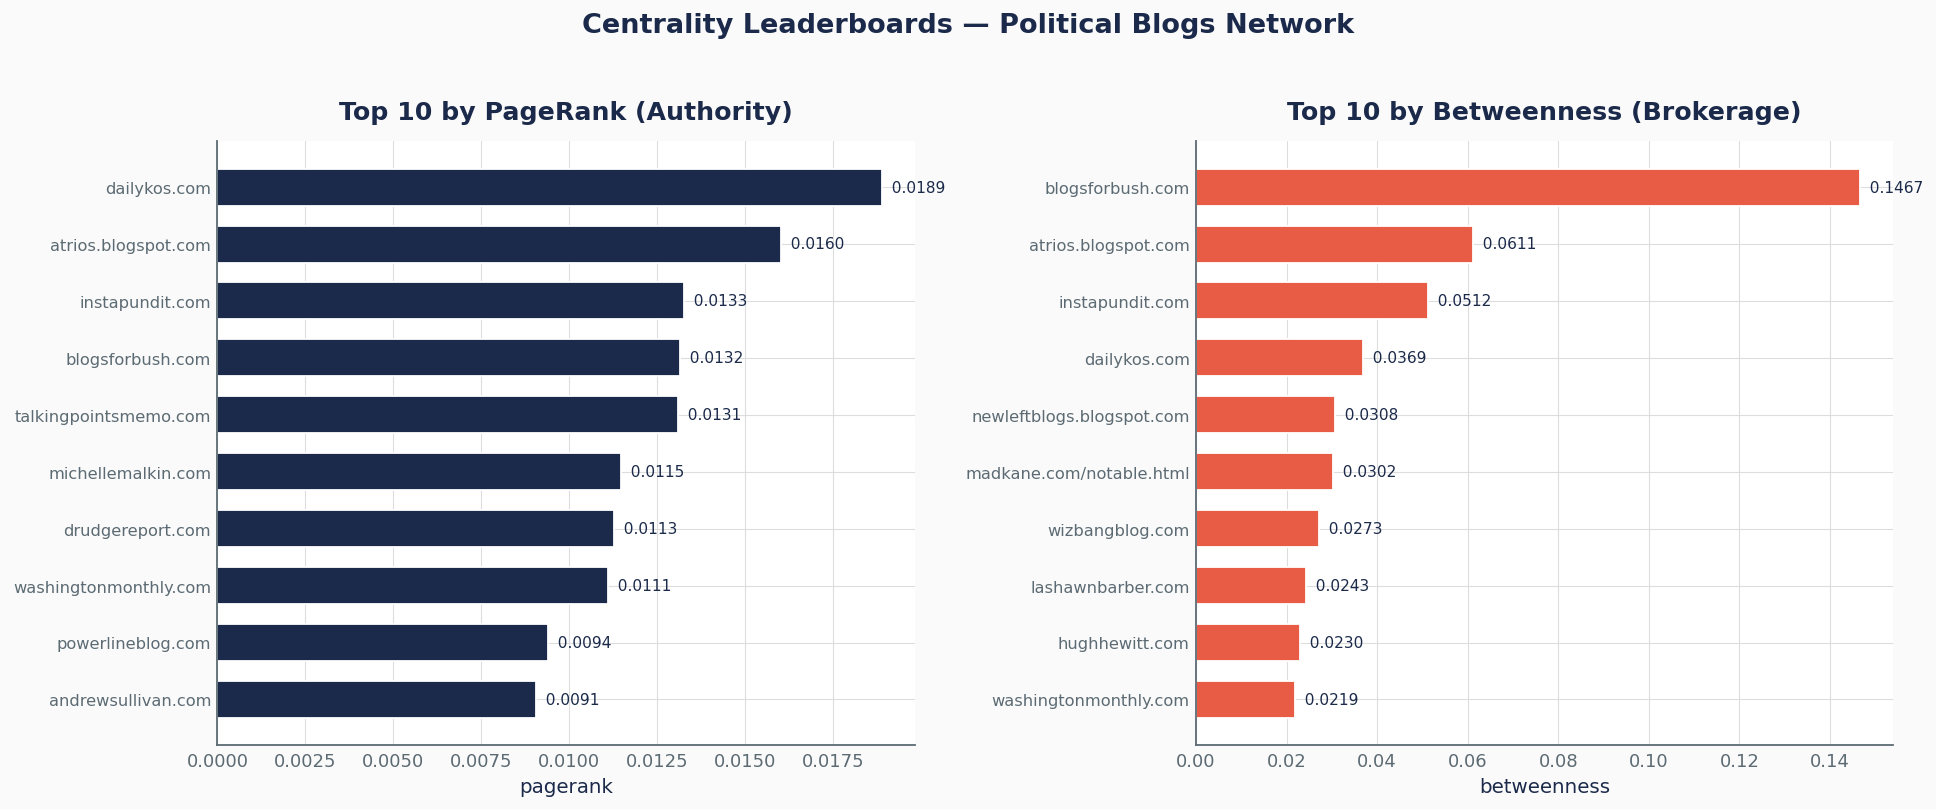

In [17]:
# ---- B.3 visual: top-10 leaderboards, side by side ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, df, title, color in zip(
    axes, [top10_pagerank, top10_betweenness],
    ["Top 10 by PageRank (Authority)", "Top 10 by Betweenness (Brokerage)"],
    [PALETTE["navy"], PALETTE["coral"]]
):
    df_plot = df.iloc[::-1]  # reverse so rank 1 is at the top of the barh
    bars = ax.barh(df_plot["label"], df_plot[df_plot.columns[2]], color=color,
                    edgecolor="white", height=0.65)
    for b, v in zip(bars, df_plot[df_plot.columns[2]]):
        ax.text(v, b.get_y() + b.get_height()/2, f"  {v:.4f}", va="center",
                fontsize=8.5, color=PALETTE["navy"])
    ax.set_title(title, pad=12)
    ax.set_xlabel(df_plot.columns[2])
    ax.tick_params(axis="y", labelsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Centrality Leaderboards — Political Blogs Network",
             fontsize=15, fontweight="bold", color=PALETTE["navy"], y=1.03)
plt.tight_layout()
plt.savefig("outputs/figures/centrality_leaderboards.png", dpi=160, bbox_inches="tight")
plt.show()


### Comparing the two rankings

We use two complementary comparisons, as required:
1. **Spearman rank correlation** across *all* nodes in the analysis graph
   — a single number in [-1, 1] summarizing overall agreement between the
   two full rankings.
2. **Top-K overlap** — how many of the same nodes appear in both top-K
   lists, which is more intuitive than a correlation coefficient ("how
   many of the same blogs would each measure send you to?").


In [18]:
# ---- B.4: Ranking comparison (Spearman correlation + top-K overlap) ----
def compare_rankings(scores_a, scores_b, top_k=50):
    common_nodes = list(scores_a.keys())
    a_vals = [scores_a[n] for n in common_nodes]
    b_vals = [scores_b[n] for n in common_nodes]
    rho, p_value = spearmanr(a_vals, b_vals)

    top_a = set(sorted(scores_a, key=scores_a.get, reverse=True)[:top_k])
    top_b = set(sorted(scores_b, key=scores_b.get, reverse=True)[:top_k])
    overlap = len(top_a & top_b)

    return {
        "spearman_rho": rho, "spearman_p_value": p_value,
        "top_k": top_k, "overlap_count": overlap,
        "overlap_pct": overlap / top_k * 100,
        "top_a_only": top_a - top_b, "top_b_only": top_b - top_a,
    }

ranking_comparison = compare_rankings(pagerank_scores, betweenness_scores, top_k=50)

pd.Series({k: v for k, v in ranking_comparison.items() if not isinstance(v, set)}).to_csv(
    "outputs/tables/ranking_comparison.csv"
)
pd.Series({k: v for k, v in ranking_comparison.items() if not isinstance(v, set)})


spearman_rho         7.575570e-01
spearman_p_value    3.059278e-228
top_k                5.000000e+01
overlap_count        2.100000e+01
overlap_pct          4.200000e+01
dtype: float64

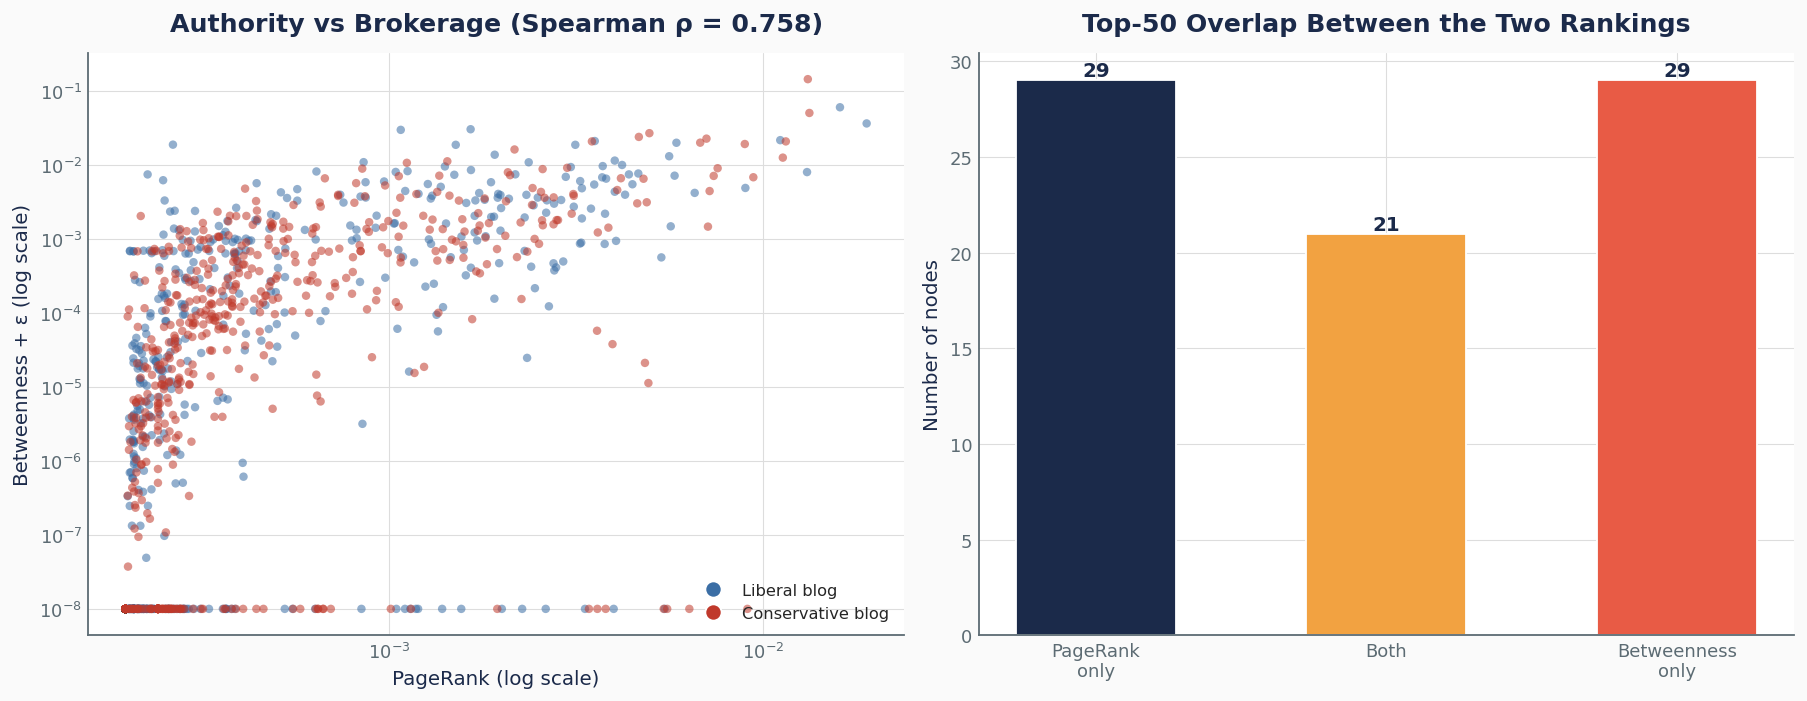

In [19]:
# ---- B.4 visual: agreement scatter plot + overlap breakdown ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: PageRank vs Betweenness scatter (log-log), colored by ground truth
ax = axes[0]
all_nodes = list(G_analysis.nodes())
pr_vals = np.array([pagerank_scores[n] for n in all_nodes])
bt_vals = np.array([betweenness_scores[n] + 1e-8 for n in all_nodes])  # tiny epsilon for log scale
colors_gt = [PALETTE["liberal"] if G_analysis.nodes[n]["value"] == 0 else PALETTE["conservative"] for n in all_nodes]

ax.scatter(pr_vals, bt_vals, s=22, alpha=0.55, c=colors_gt, edgecolors="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("PageRank (log scale)"); ax.set_ylabel("Betweenness + \u03b5 (log scale)")
ax.set_title(f"Authority vs Brokerage (Spearman \u03c1 = {ranking_comparison['spearman_rho']:.3f})", pad=12)
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="Liberal blog", markerfacecolor=PALETTE["liberal"], markersize=9),
    plt.Line2D([0], [0], marker="o", color="w", label="Conservative blog", markerfacecolor=PALETTE["conservative"], markersize=9),
]
ax.legend(handles=legend_handles, fontsize=9, loc="lower right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Panel 2: top-50 overlap breakdown (simple 3-bar view instead of a proportional venn)
ax = axes[1]
overlap_data = [
    ("PageRank\nonly", len(ranking_comparison["top_a_only"]), PALETTE["navy"]),
    ("Both", ranking_comparison["overlap_count"], PALETTE["gold"]),
    ("Betweenness\nonly", len(ranking_comparison["top_b_only"]), PALETTE["coral"]),
]
labels_, counts_, colors_ = zip(*overlap_data)
bars = ax.bar(labels_, counts_, color=colors_, width=0.55, edgecolor="white")
for b, v in zip(bars, counts_):
    ax.text(b.get_x() + b.get_width()/2, v, str(v), ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=PALETTE["navy"])
ax.set_title(f"Top-{ranking_comparison['top_k']} Overlap Between the Two Rankings", pad=12)
ax.set_ylabel("Number of nodes")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/figures/centrality_ranking_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


### Interpreting important nodes

The assignment requires interpreting at least three important nodes in
*network terms* (not just declaring "this blog is important in real
life" — a high score alone does not prove real-world political
importance). The cell below generates this interpretation directly from
the computed results, so it is always consistent with whatever data
produced the tables above.


In [20]:
# ---- B.5: Data-driven interpretation of key nodes ----
top_pr_node = top10_pagerank.iloc[0]
top_bt_node = top10_betweenness.iloc[0]

# a node that ranks highly on BOTH measures, if one exists in the top 10 of each
both_top10 = set(top10_pagerank["node_id"]) & set(top10_betweenness["node_id"])
dual_node_label = None
if both_top10:
    dual_id = next(iter(both_top10))
    dual_node_label = G_analysis.nodes[dual_id].get("label", dual_id)

print(f"1) '{top_pr_node['label']}' has the highest PageRank ({top_pr_node['pagerank']:.4f}).")
print("   Network-term interpretation: many other blogs — including other high-scoring")
print("   ones — link to it, so its authority is earned recursively, not just from raw")
print("   link count. This is exactly the kind of node PageRank is designed to surface,")
print("   and it does NOT necessarily mean it is also a structural bridge (see betweenness).")

print(f"\n2) '{top_bt_node['label']}' has the highest Betweenness ({top_bt_node['betweenness']:.4f}).")
print("   Network-term interpretation: this node lies on an unusually large share of the")
print("   shortest paths connecting other blog pairs. Structurally, removing it would force")
print("   many blog-to-blog information paths to become longer or disappear altogether —")
print("   it behaves as a bridge/broker rather than (necessarily) a popular authority.")

if dual_node_label:
    print(f"\n3) '{dual_node_label}' appears in the TOP 10 of BOTH measures.")
    print("   Network-term interpretation: this is a rare dual role — a node that is both a")
    print("   recursively-endorsed authority AND a structural bridge. Such nodes are the most")
    print("   'systemically important': their removal would simultaneously reduce the")
    print("   network's overall authority signal and fragment its connectivity.")
else:
    print("\n3) No single node appears in the top 10 of both measures in this run —")
    print("   this itself is an interpretable finding: authority and brokerage are")
    print(f"   distinct roles here (consistent with the moderate Spearman correlation of")
    print(f"   {ranking_comparison['spearman_rho']:.3f} computed above), played by different blogs.")

print("\nCaveat (as required by the assignment): a high centrality score describes the")
print("blog's position in the LINK graph only. It does not, by itself, prove real-world")
print("political influence — a blog could be heavily linked for reasons unrelated to its")
print("actual persuasive power (e.g. being an early/foundational blog in its niche).")


1) 'dailykos.com' has the highest PageRank (0.0189).
   Network-term interpretation: many other blogs — including other high-scoring
   ones — link to it, so its authority is earned recursively, not just from raw
   link count. This is exactly the kind of node PageRank is designed to surface,
   and it does NOT necessarily mean it is also a structural bridge (see betweenness).

2) 'blogsforbush.com' has the highest Betweenness (0.1467).
   Network-term interpretation: this node lies on an unusually large share of the
   shortest paths connecting other blog pairs. Structurally, removing it would force
   many blog-to-blog information paths to become longer or disappear altogether —
   it behaves as a bridge/broker rather than (necessarily) a popular authority.

3) 'blogsforbush.com' appears in the TOP 10 of BOTH measures.
   Network-term interpretation: this is a rare dual role — a node that is both a
   recursively-endorsed authority AND a structural bridge. Such nodes are the most
   